STEP 1: Install Library

In [ ]:
!pip install dice-ml

STEP 2: Import Libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

import dice_ml
from dice_ml import Dice

STEP 3: Load Dataset (UCI FILE)

In [ ]:
# Column names from wdbc.names
columns = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]
df = pd.read_csv("wdbc.data", header=None, names=columns)

STEP 4: Preprocessing

In [ ]:
# Drop ID column
df = df.drop("id", axis=1)

# Convert diagnosis (M=1, B=0)
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

STEP 5: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42
)

STEP 6: Train Model

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

STEP 7: Evaluation

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9649122807017544
Confusion Matrix:
 [[70  1]
 [ 3 40]]


STEP 8: Prepare DiCE

In [ ]:
train_data = X_train.copy()
train_data["diagnosis"] = y_train

data_dice = dice_ml.Data(
    dataframe=train_data,
    continuous_features=X.columns.tolist(),
    outcome_name="diagnosis"
)

model_dice = dice_ml.Model(model=model, backend="sklearn")
exp = Dice(data_dice, model_dice, method="random")

STEP 9: Counterfactuals

In [ ]:
query_instance = X_test.iloc[0:1]

print("\nOriginal Prediction:", model.predict(query_instance))

cf = exp.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_class="opposite"
)


Original Prediction: [0]


100%|██████████| 1/1 [00:00<00:00,  1.06it/s]


STEP 10: Show Results

In [ ]:
cf.visualize_as_dataframe()

Query instance (original outcome : 0)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,-0.470694,-0.160486,-0.44811,-0.491999,0.234114,0.027651,-0.109847,-0.276232,0.413949,0.132176,...,-0.168905,-0.333935,-0.356299,0.448503,-0.104741,-0.024412,-0.199563,0.183204,0.196958,0



Diverse Counterfactual set (new outcome: 1)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,-0.470694,-0.160486,-0.44811,-0.491999,0.234114,0.027651,-0.109847,-0.276232,0.413949,0.132176,...,-0.168905,-0.333935,1.023236,0.448503,-0.104741,-0.024412,-0.199563,0.183204,0.196958,1
1,-0.470694,-0.160486,-0.44811,-0.491999,0.234114,0.027651,-0.109847,-0.276232,0.413949,0.132176,...,-0.168905,-0.333935,3.958674,0.448503,-0.104741,-0.024412,-0.199563,0.183204,0.196958,1
2,-0.470694,-0.160486,-0.44811,-0.491999,0.234114,0.027651,-0.109847,-0.276232,0.413949,0.132176,...,-0.168905,-0.333935,2.097549,0.448503,-0.104741,-0.024412,-0.199563,0.183204,0.196958,1


Step 11: Confusion Matrix Visualization

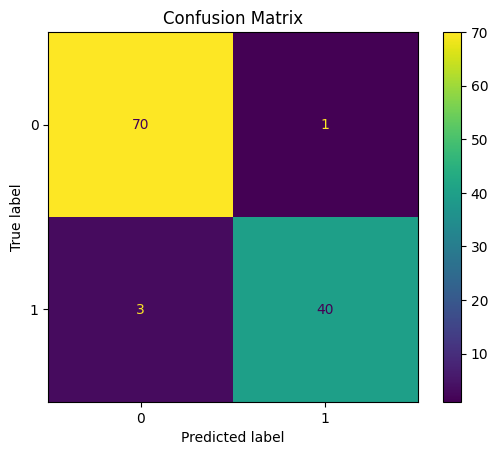

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()
plt.title("Confusion Matrix")
plt.show()

Step 12: Feature Importance Graph

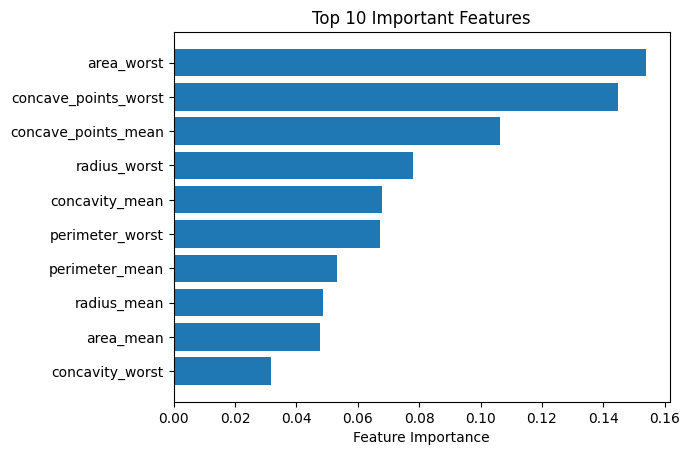

In [ ]:
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10 features

plt.figure()
plt.title("Top 10 Important Features")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Feature Importance")
plt.show()

Step 13: Prediction Distribution

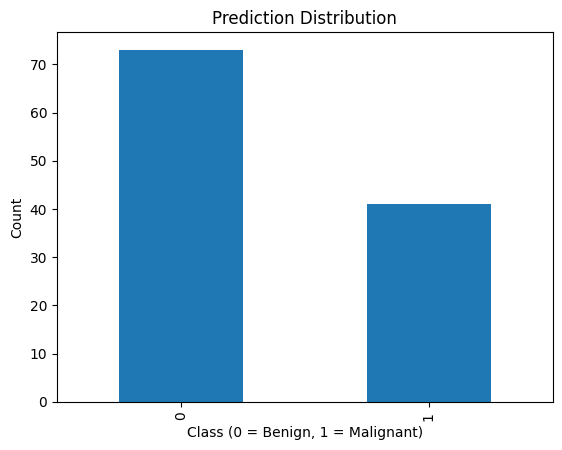

In [ ]:
import pandas as pd

pred_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

pred_df["Predicted"].value_counts().plot(kind="bar")
plt.title("Prediction Distribution")
plt.xlabel("Class (0 = Benign, 1 = Malignant)")
plt.ylabel("Count")
plt.show()

Step 14: Probability Confidence Plot

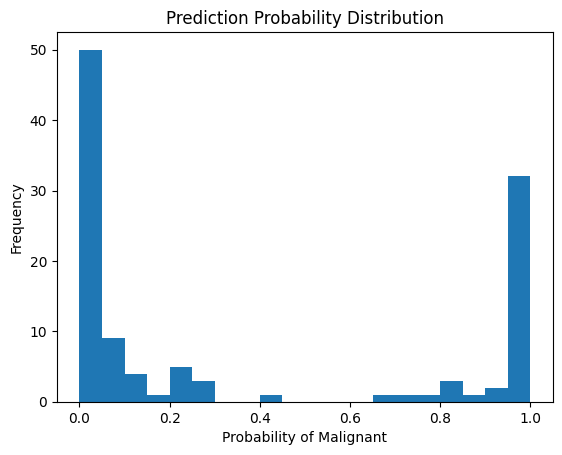

In [ ]:
y_prob = model.predict_proba(X_test)[:,1]

plt.figure()
plt.hist(y_prob, bins=20)
plt.title("Prediction Probability Distribution")
plt.xlabel("Probability of Malignant")
plt.ylabel("Frequency")
plt.show()

Step 15: Counterfactual Visualization

In [ ]:
# Extract original and CF
original = query_instance.iloc[0]
cf_df = cf.cf_examples_list[0].final_cfs_df

print("Original Instance:\n", original)
print("\nCounterfactual Examples:\n", cf_df)

Original Instance:
 radius_mean               -0.470694
texture_mean              -0.160486
perimeter_mean            -0.448110
area_mean                 -0.491999
smoothness_mean            0.234114
compactness_mean           0.027651
concavity_mean            -0.109847
concave_points_mean       -0.276232
symmetry_mean              0.413949
fractal_dimension_mean     0.132176
radius_se                 -0.032743
texture_se                -0.313616
perimeter_se              -0.182696
area_se                   -0.221053
smoothness_se             -0.029327
compactness_se            -0.355912
concavity_se              -0.161929
concave_points_se         -0.231333
symmetry_se               -0.329612
fractal_dimension_se      -0.079018
radius_worst              -0.269040
texture_worst             -0.168905
perimeter_worst           -0.333935
area_worst                -0.356299
smoothness_worst           0.448503
compactness_worst         -0.104741
concavity_worst           -0.024412
concave_

Step 16: Correlation Heatmap

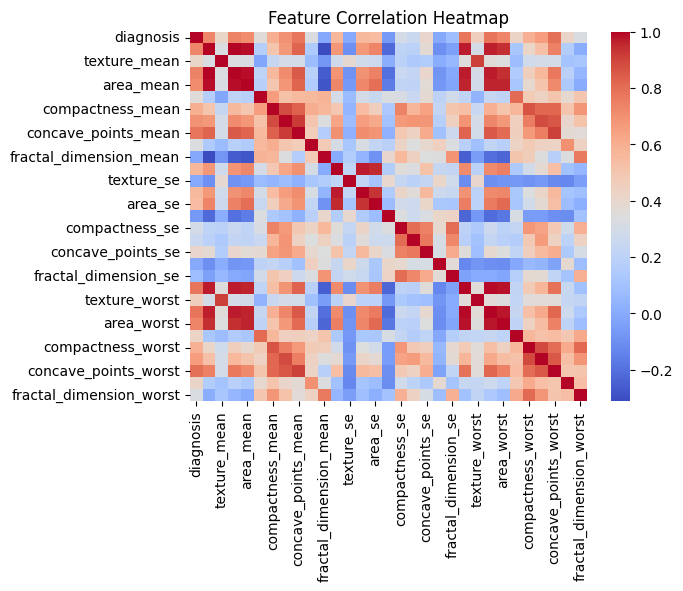

In [ ]:
import seaborn as sns

plt.figure()
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()